# Evaluation Plots
This notebook generates all figures for Chapter 4 (Results and Discussion).

In [76]:
import json
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

os.makedirs('figures', exist_ok=True)

# ── Colour palette ──────────────────────────────────────────────────────────
COLORS = {
    'sonnet':  '#2196F3',   # blue
    'deepseek': '#FF9800',  # orange
    'qwen':    '#4CAF50',   # green
}
LABELS = {
    'sonnet':  'Claude Sonnet 4.6',
    'deepseek': 'DeepSeek V3.2',
    'qwen':    'Qwen 3.5 9B',
}
MODELS = ['sonnet', 'deepseek', 'qwen']

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 150,
})

In [77]:
# ── Load all six result files ────────────────────────────────────────────────
def load(name):
    with open(f'jaccard_results_{name}.json') as f:
        return json.load(f)

data = {
    'sonnet':        load('sonnet_3'),
    'sonnet_onto':   load('sonnet_onto_3'),
    'deepseek':      load('deepseek_3'),
    'deepseek_onto': load('deepseek_onto_3'),
    'qwen':          load('qwen_3'),
    'qwen_onto':     load('qwen_onto_3'),
}

# Convenience getters
def m(model, onto, key):
    k = f'{model}_onto' if onto else model
    return data[k][key]

def cat(model, onto, category, key):
    k = f'{model}_onto' if onto else model
    return data[k]['by_category'][category][key]

print('Data loaded.')
for k, d in data.items():
    print(f"  {k}: {d['questions_evaluated']}/{d['questions_total']} evaluated")

Data loaded.
  sonnet: 30/30 evaluated
  sonnet_onto: 30/30 evaluated
  deepseek: 30/30 evaluated
  deepseek_onto: 30/30 evaluated
  qwen: 24/30 evaluated
  qwen_onto: 24/30 evaluated


## 4.2.1 – Overall comparison across models (no ontology)

/var/folders/5n/w_pvtlp11bn1mz7793gp36ww0000gp/T/ipykernel_1524/1340981873.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([LABELS[model].replace(' ', '\n') for model in MODELS], fontsize=9)
/var/folders/5n/w_pvtlp11bn1mz7793gp36ww0000gp/T/ipykernel_1524/1340981873.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([LABELS[model].replace(' ', '\n') for model in MODELS], fontsize=9)
/var/folders/5n/w_pvtlp11bn1mz7793gp36ww0000gp/T/ipykernel_1524/1340981873.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([LABELS[model].replace(' ', '\n') for model in MODELS], fontsize=9)
/var/folders/5n/w_pvtlp11bn1mz7793gp36ww0000gp/T/ipykernel_1524/1340981873.py:23: UserWarning: set_tick

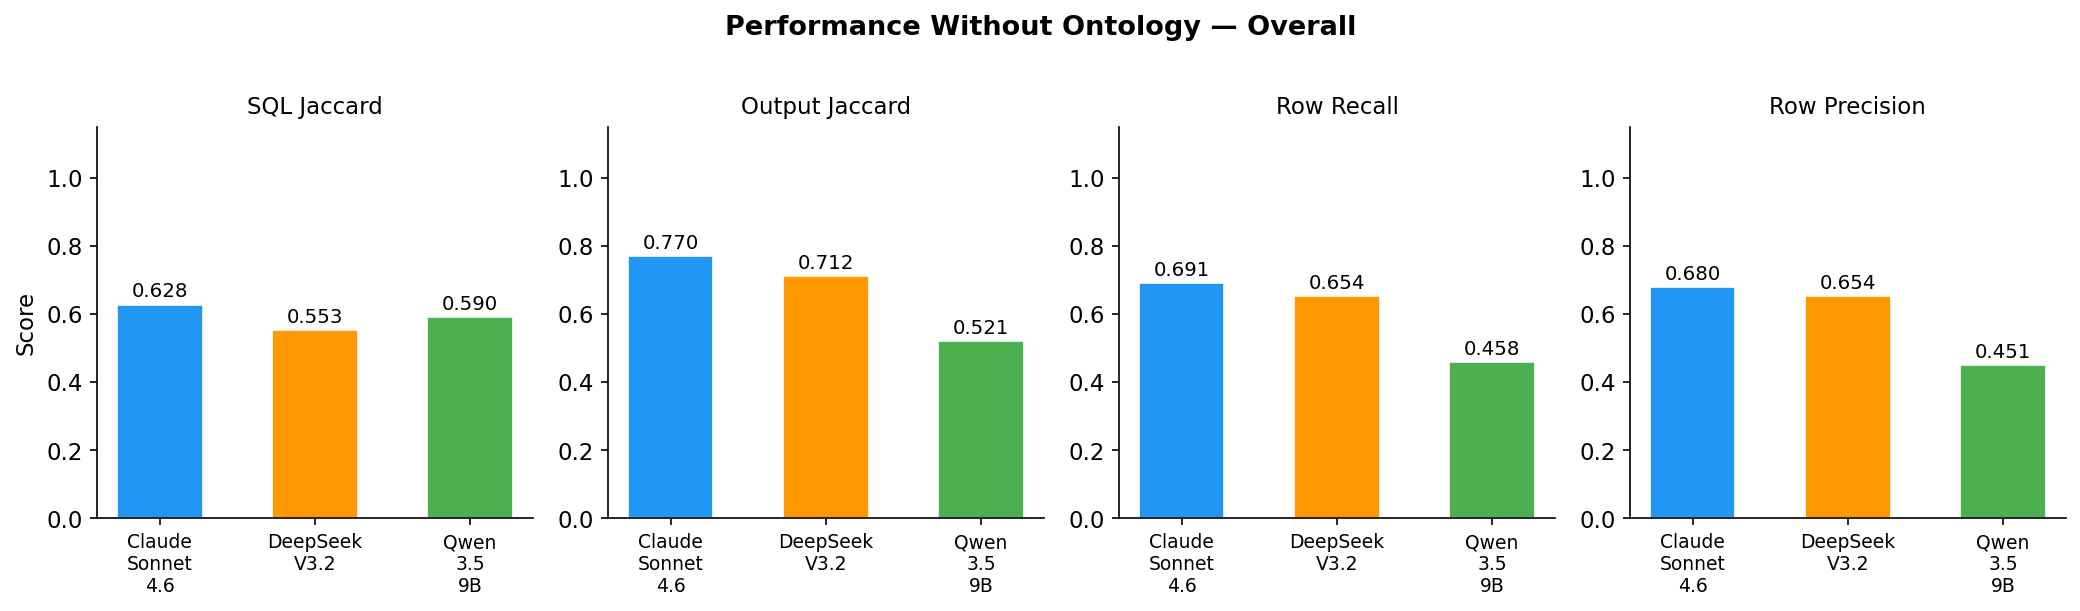

In [78]:
metrics = [
    ('mean_jaccard_similarity_sql',    'SQL Jaccard'),
    ('mean_jaccard_similarity_output', 'Output Jaccard'),
    ('mean_row_recall_output',         'Row Recall'),
    ('mean_row_precision_output',      'Row Precision'),
]

fig, axes = plt.subplots(1, 4, figsize=(14, 4), sharey=False)
fig.suptitle('Performance Without Ontology — Overall', fontsize=13, fontweight='bold', y=1.01)

for ax, (key, label) in zip(axes, metrics):
    values = [m(model, onto=False, key=key) for model in MODELS]
    colors = [COLORS[model] for model in MODELS]
    bars = ax.bar([LABELS[model] for model in MODELS], values, color=colors,
                  edgecolor='white', linewidth=0.8, width=0.55)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9.5)
    ax.set_title(label, fontsize=11)
    ax.set_ylim(0, 1.15)
    ax.set_ylabel('Score' if ax == axes[0] else '')
    ax.tick_params(axis='x', labelsize=9)
    ax.set_xticklabels([LABELS[model].replace(' ', '\n') for model in MODELS], fontsize=9)

plt.tight_layout()
plt.savefig('figures/4_2_1_overall_base.png', dpi=300, bbox_inches='tight')
plt.show()

## 4.2.2 – Breakdown by question complexity (no ontology)

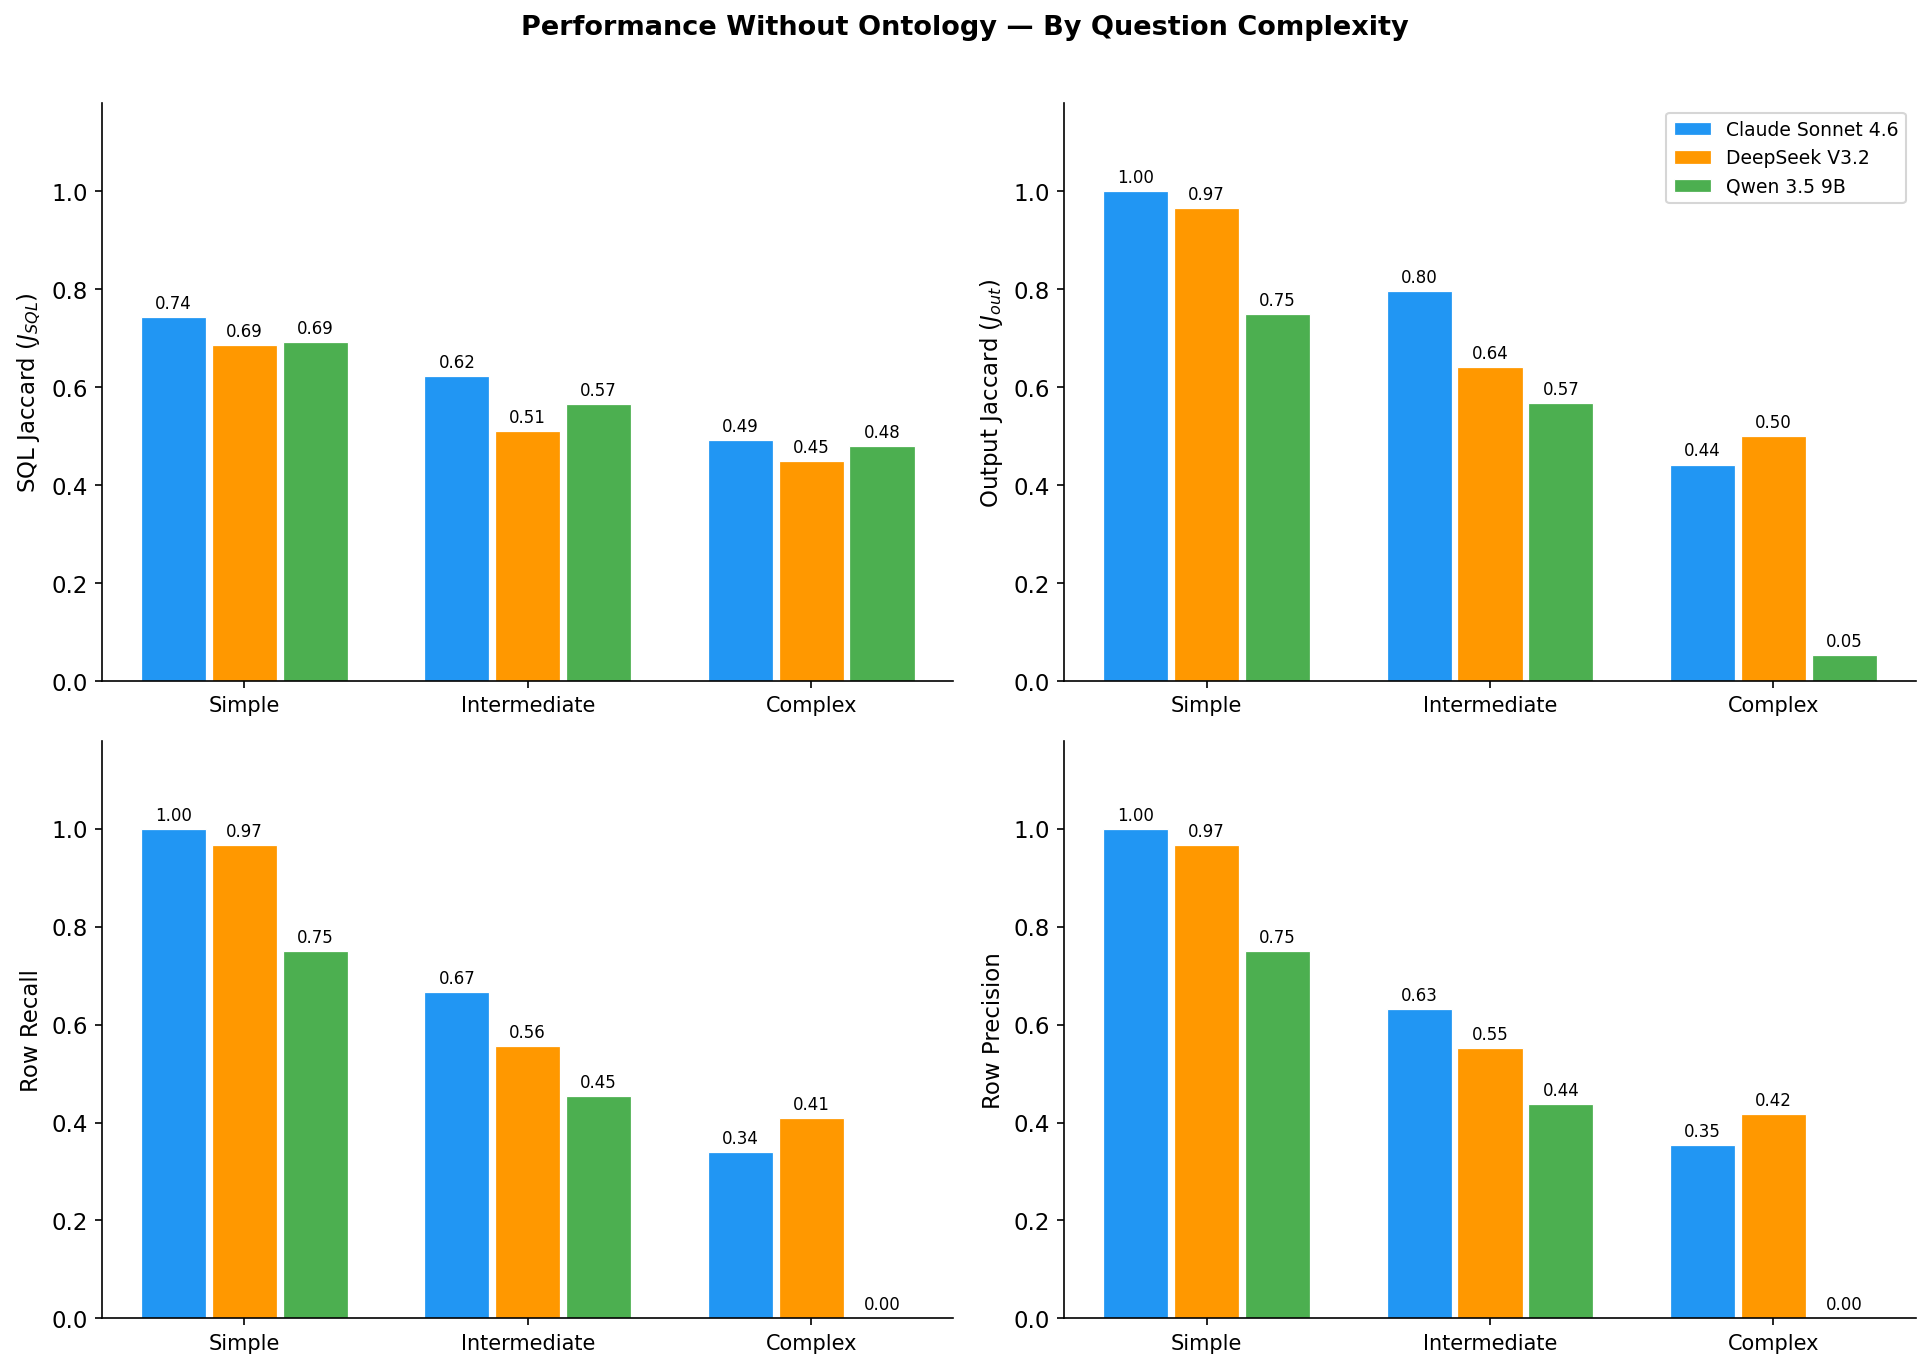

In [79]:
categories = ['simple', 'intermediate', 'complex']
cat_labels  = ['Simple', 'Intermediate', 'Complex']

plot_keys = [
    ('mean_jaccard_similarity_sql',    'SQL Jaccard ($J_{SQL}$)'),
    ('mean_jaccard_similarity_output', 'Output Jaccard ($J_{out}$)'),
    ('mean_row_recall_output',         'Row Recall'),
    ('mean_row_precision_output',      'Row Precision'),
]

x = np.arange(len(categories))
width = 0.25
offsets = [-width, 0, width]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('Performance Without Ontology — By Question Complexity',
             fontsize=13, fontweight='bold', y=1.01)

for idx, (ax, (key, ylabel)) in enumerate(zip(axes.flat, plot_keys)):
    for i, model in enumerate(MODELS):
        vals = [cat(model, onto=False, category=c, key=key) for c in categories]
        bars = ax.bar(x + offsets[i], vals, width=width - 0.02,
                      color=COLORS[model], label=LABELS[model],
                      edgecolor='white', linewidth=0.6)
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.01,
                    f'{val:.2f}', ha='center', va='bottom', fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(cat_labels, fontsize=10)
    ax.set_ylim(0, 1.18)
    ax.set_ylabel(ylabel)
    if idx == 1:  # top-right only
        ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('figures/4_2_2_complexity_base.png', dpi=300, bbox_inches='tight')
plt.show()

## 4.3.1 – Overall comparison across models (with ontology)

/var/folders/5n/w_pvtlp11bn1mz7793gp36ww0000gp/T/ipykernel_1524/250681561.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([LABELS[model].replace(' ', '\n') for model in MODELS], fontsize=9)
/var/folders/5n/w_pvtlp11bn1mz7793gp36ww0000gp/T/ipykernel_1524/250681561.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([LABELS[model].replace(' ', '\n') for model in MODELS], fontsize=9)
/var/folders/5n/w_pvtlp11bn1mz7793gp36ww0000gp/T/ipykernel_1524/250681561.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([LABELS[model].replace(' ', '\n') for model in MODELS], fontsize=9)
/var/folders/5n/w_pvtlp11bn1mz7793gp36ww0000gp/T/ipykernel_1524/250681561.py:15: UserWarning: set_ticklabe

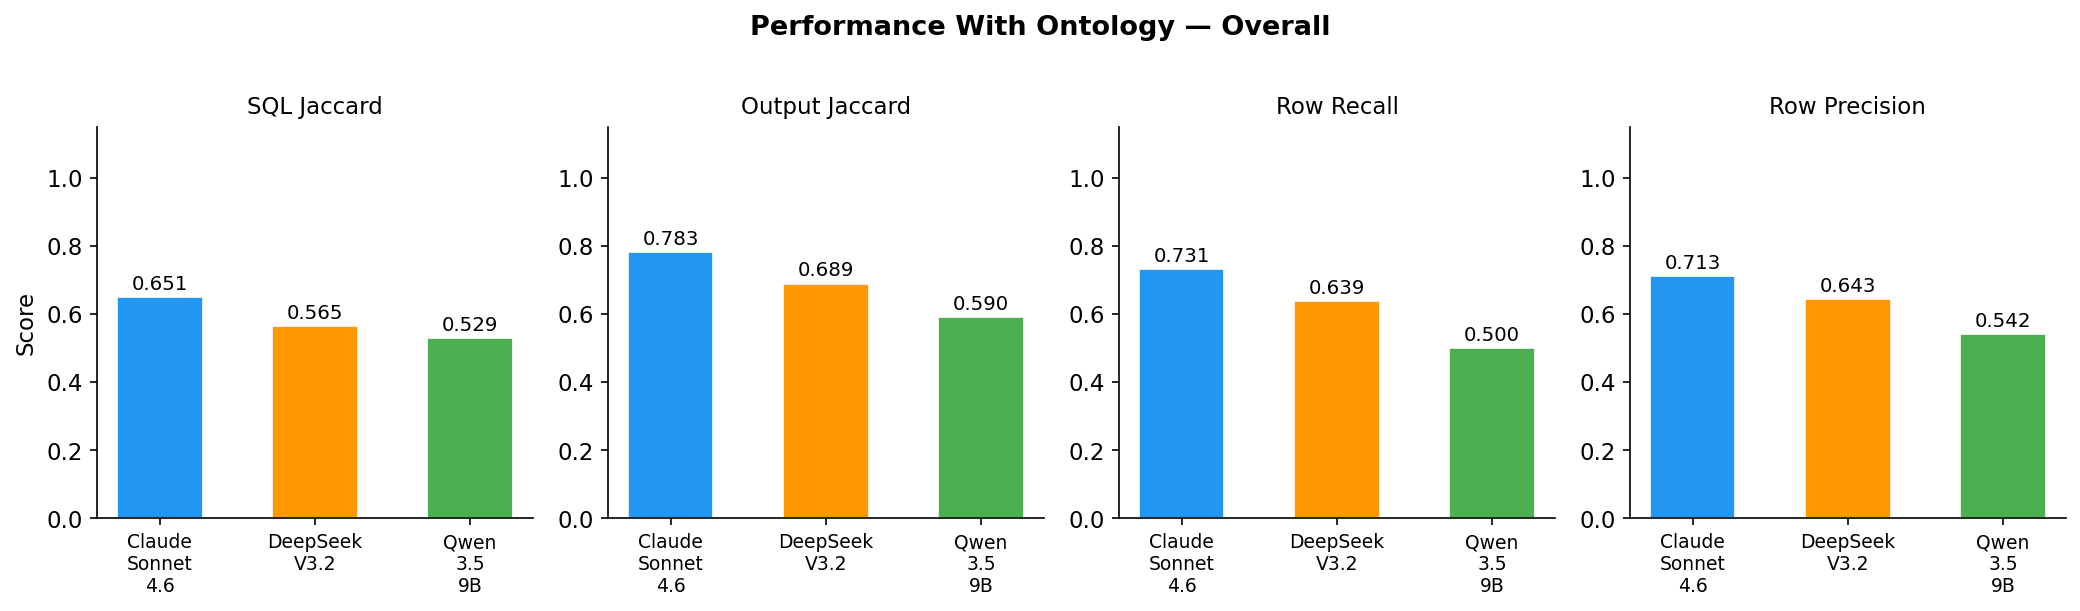

In [80]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4), sharey=False)
fig.suptitle('Performance With Ontology — Overall', fontsize=13, fontweight='bold', y=1.01)

for ax, (key, label) in zip(axes, metrics):
    values = [m(model, onto=True, key=key) for model in MODELS]
    colors = [COLORS[model] for model in MODELS]
    bars = ax.bar([LABELS[model] for model in MODELS], values, color=colors,
                  edgecolor='white', linewidth=0.8, width=0.55)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9.5)
    ax.set_title(label, fontsize=11)
    ax.set_ylim(0, 1.15)
    ax.set_ylabel('Score' if ax == axes[0] else '')
    ax.set_xticklabels([LABELS[model].replace(' ', '\n') for model in MODELS], fontsize=9)

plt.tight_layout()
plt.savefig('figures/4_3_1_overall_onto.png', dpi=300, bbox_inches='tight')
plt.show()

## 4.3.2 – Breakdown by question complexity (with ontology)

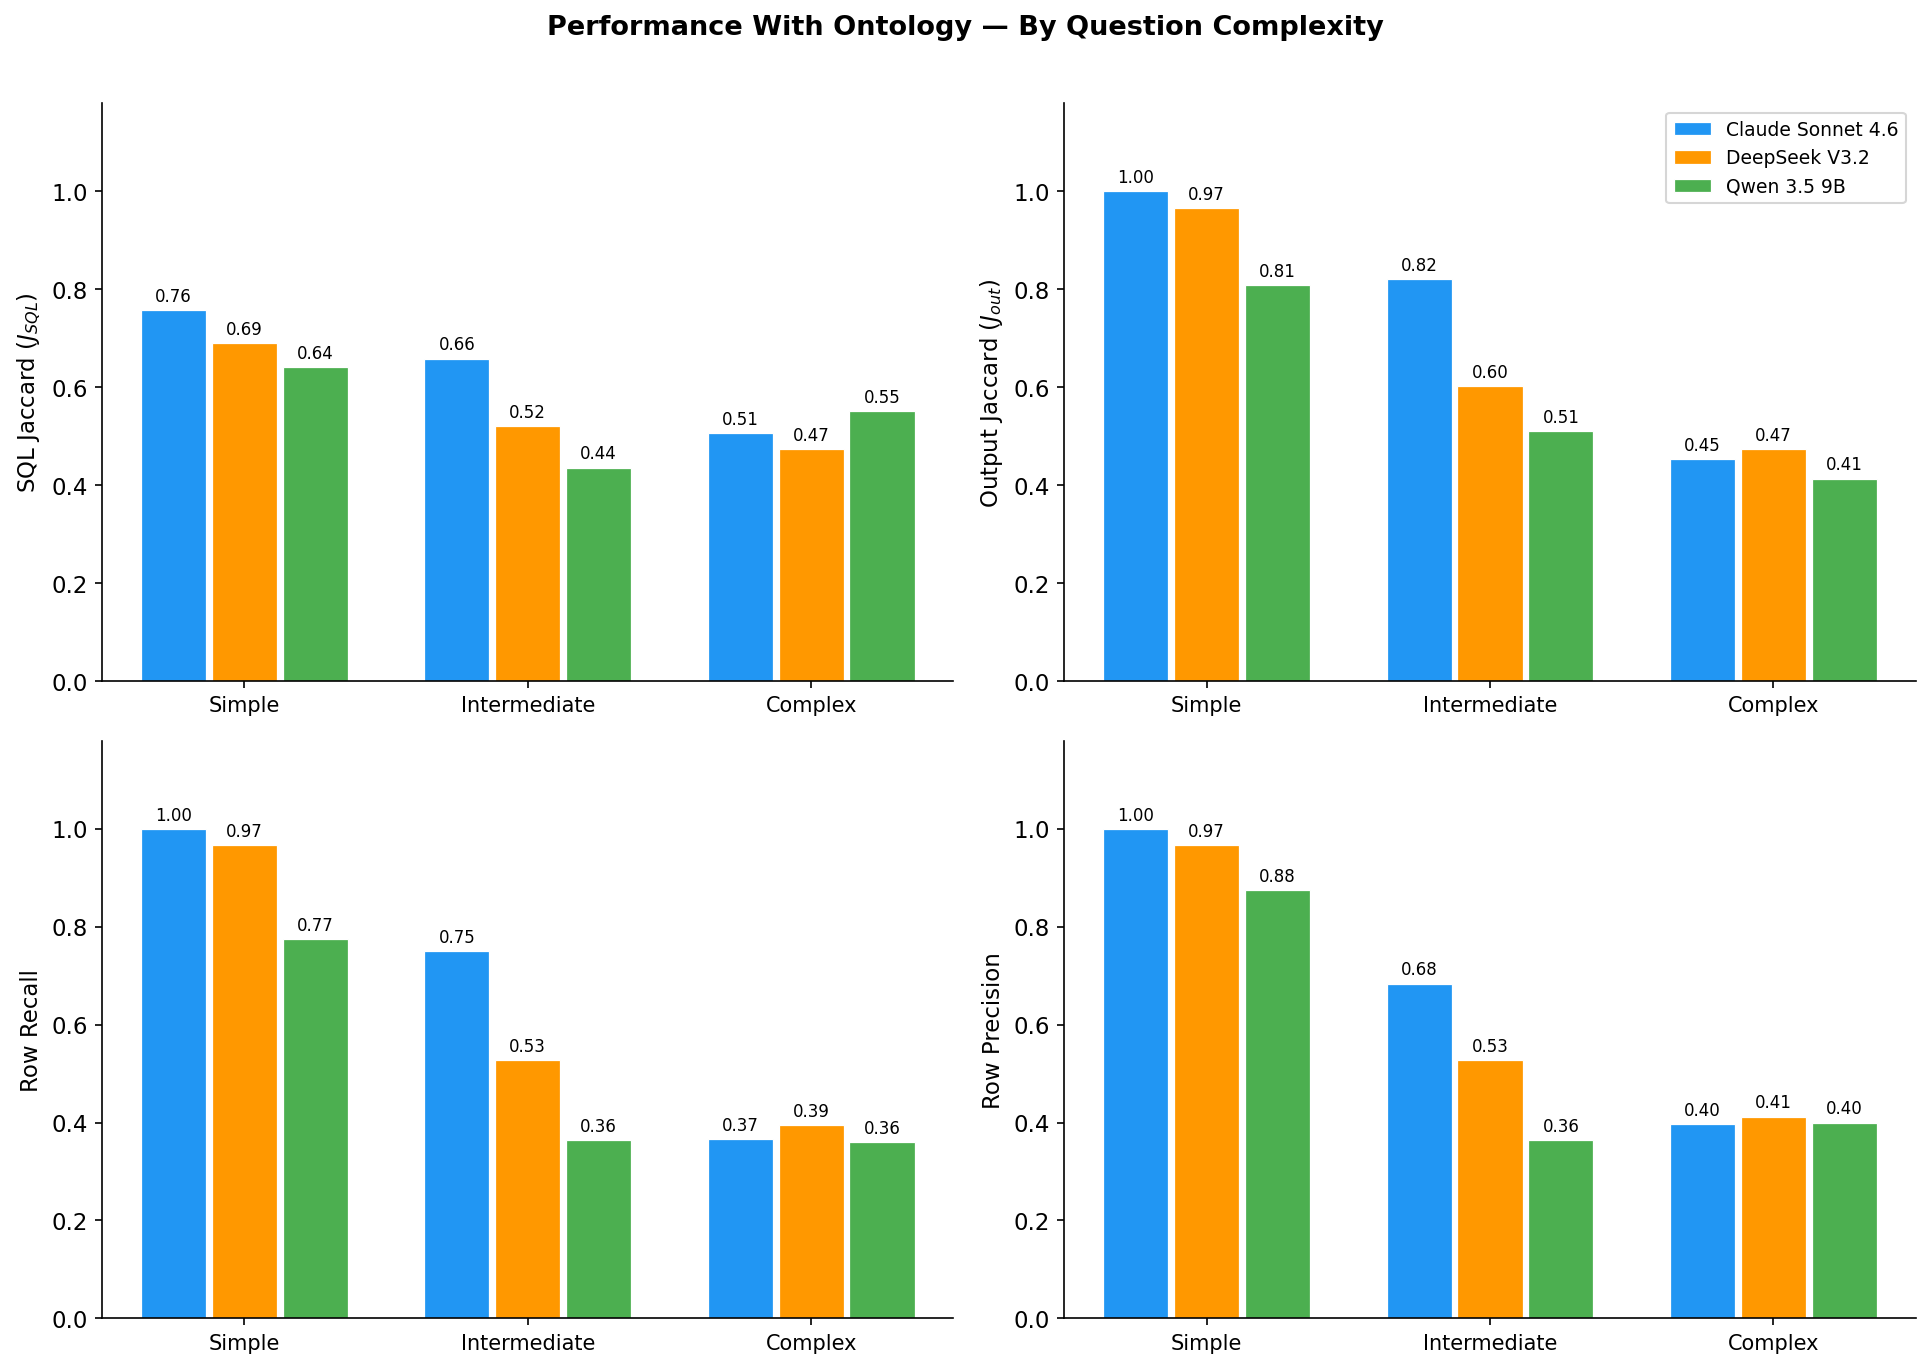

In [81]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('Performance With Ontology — By Question Complexity',
             fontsize=13, fontweight='bold', y=1.01)

for idx, (ax, (key, ylabel)) in enumerate(zip(axes.flat, plot_keys)):
    for i, model in enumerate(MODELS):
        vals = [cat(model, onto=True, category=c, key=key) for c in categories]
        bars = ax.bar(x + offsets[i], vals, width=width - 0.02,
                      color=COLORS[model], label=LABELS[model],
                      edgecolor='white', linewidth=0.6)
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.01,
                    f'{val:.2f}', ha='center', va='bottom', fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(cat_labels, fontsize=10)
    ax.set_ylim(0, 1.18)
    ax.set_ylabel(ylabel)
    if idx == 1:  # top-right only
        ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('figures/4_3_2_complexity_onto.png', dpi=300, bbox_inches='tight')
plt.show()

## 4.4 – Ontology Contribution by Model (delta plot)

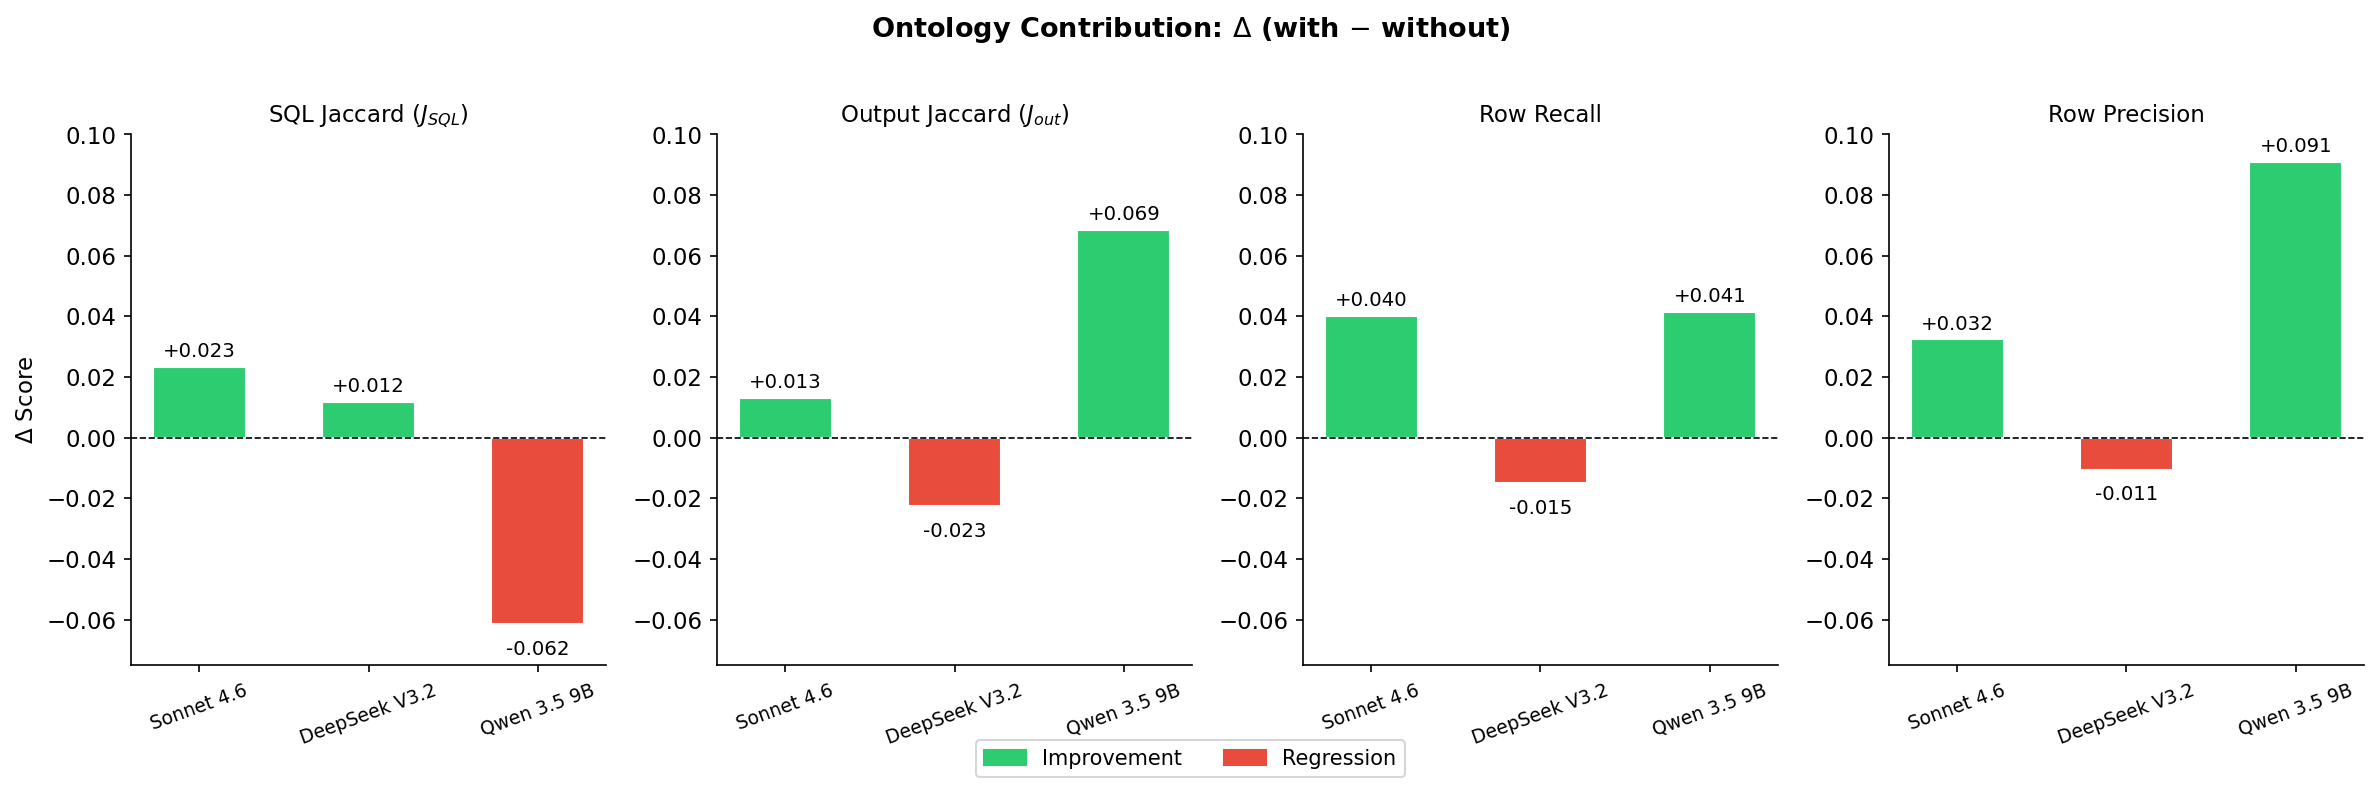

In [82]:
delta_metrics = [
    ('mean_jaccard_similarity_sql',    'SQL Jaccard ($J_{SQL}$)'),
    ('mean_jaccard_similarity_output', 'Output Jaccard ($J_{out}$)'),
    ('mean_row_recall_output',         'Row Recall'),
    ('mean_row_precision_output',      'Row Precision'),
]

SHORT_LABELS = ['Sonnet 4.6', 'DeepSeek V3.2', 'Qwen 3.5 9B']

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.suptitle('Ontology Contribution: $\\Delta$ (with $-$ without)',
             fontsize=13, fontweight='bold', y=1.01)

for ax, (key, label) in zip(axes, delta_metrics):
    deltas = [m(model, onto=True, key=key) - m(model, onto=False, key=key)
              for model in MODELS]
    colors = ['#2ecc71' if d >= 0 else '#e74c3c' for d in deltas]
    bars = ax.bar(SHORT_LABELS, deltas, color=colors, edgecolor='white', width=0.55)
    for bar, val in zip(bars, deltas):
        ypos = bar.get_height() + 0.002 if val >= 0 else bar.get_height() - 0.005
        va   = 'bottom' if val >= 0 else 'top'
        ax.text(bar.get_x() + bar.get_width() / 2, ypos,
                f'{val:+.3f}', ha='center', va=va, fontsize=9.5)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(label, fontsize=11)
    ax.set_ylabel('$\\Delta$ Score' if ax == axes[0] else '')
    ax.set_ylim(-0.075, 0.100)
    ax.tick_params(axis='x', labelsize=9, rotation=20, pad=4)

pos_patch = mpatches.Patch(color='#2ecc71', label='Improvement')
neg_patch = mpatches.Patch(color='#e74c3c', label='Regression')
fig.legend(handles=[pos_patch, neg_patch], loc='lower center',
           ncol=2, bbox_to_anchor=(0.5, -0.02), fontsize=10)

plt.tight_layout()
plt.savefig('figures/4_4_ontology_delta.png', dpi=300, bbox_inches='tight')
plt.show()

## 4.4 – Ontology Contribution by Complexity Tier (Qwen highlight)

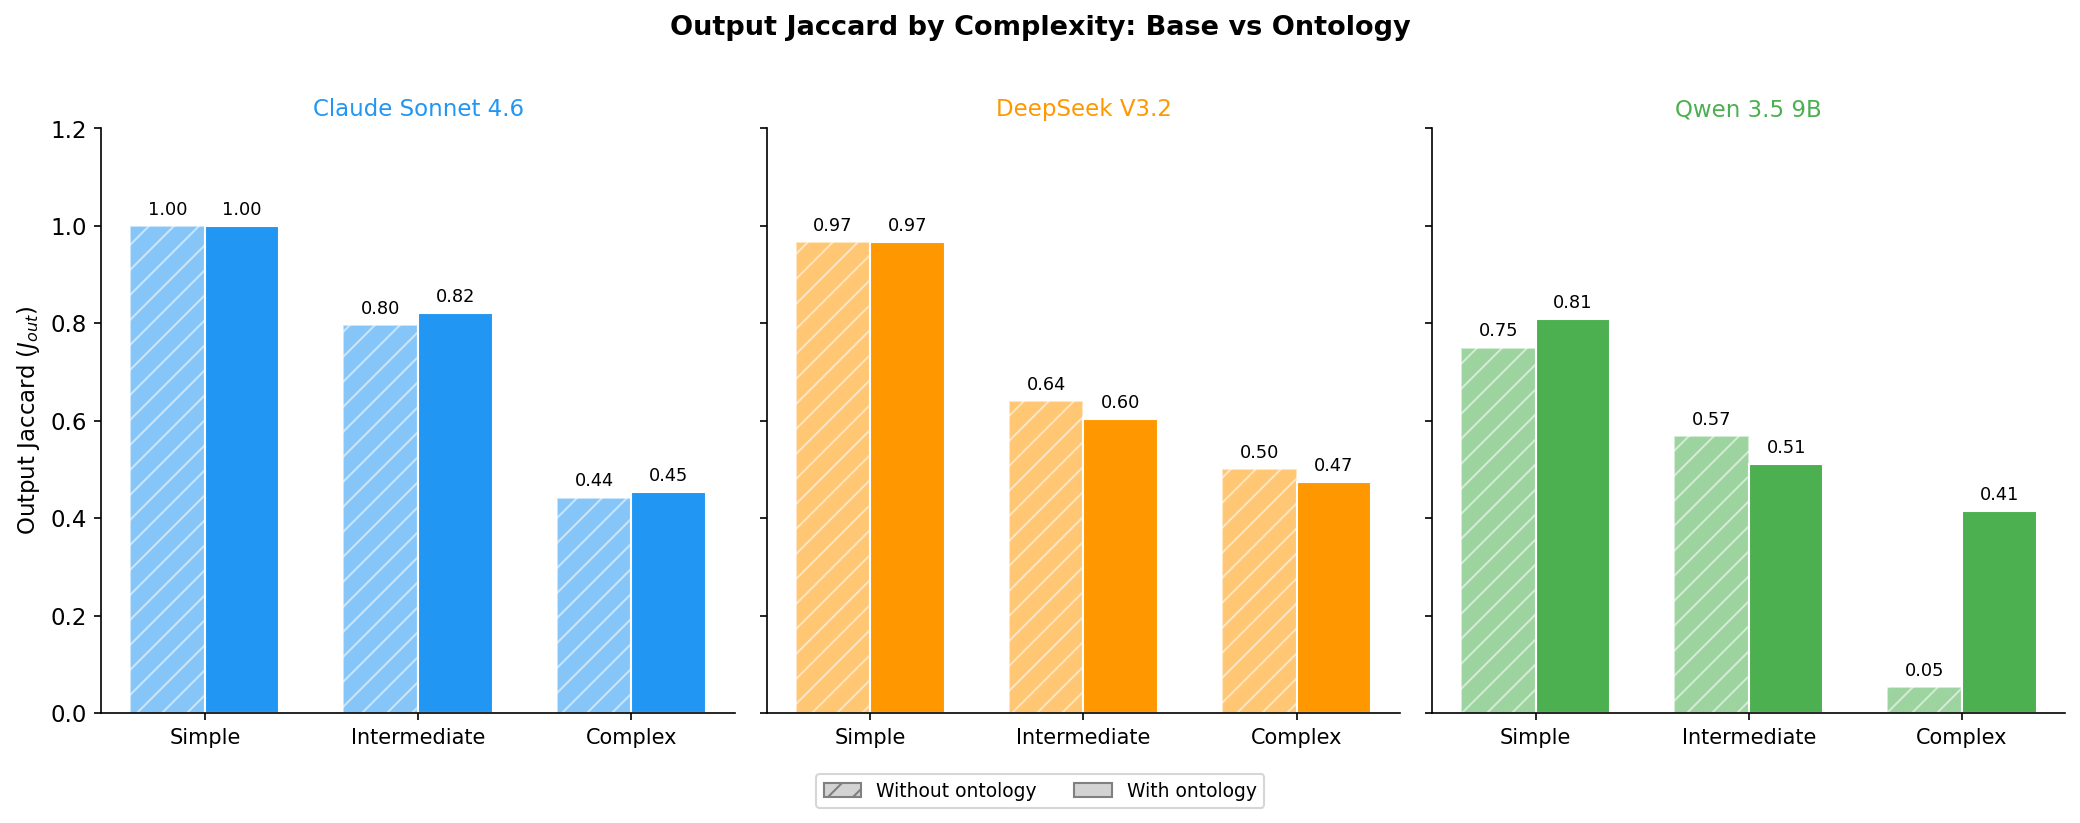

In [83]:
# Side-by-side base vs onto for J_out, split by category, one panel per model
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)
fig.suptitle('Output Jaccard by Complexity: Base vs Ontology',
             fontsize=13, fontweight='bold', y=1.01)

x = np.arange(len(categories))
w = 0.35

for ax, model in zip(axes, MODELS):
    base_vals = [cat(model, onto=False, category=c,
                     key='mean_jaccard_similarity_output') for c in categories]
    onto_vals = [cat(model, onto=True,  category=c,
                     key='mean_jaccard_similarity_output') for c in categories]

    b1 = ax.bar(x - w/2, base_vals, width=w, color=COLORS[model],
                alpha=0.55, edgecolor='white', hatch='//')
    b2 = ax.bar(x + w/2, onto_vals, width=w, color=COLORS[model],
                alpha=1.0, edgecolor='white')

    for bars in [b1, b2]:
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.015,
                    f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8.5)

    ax.set_title(LABELS[model], fontsize=11, color=COLORS[model])
    ax.set_xticks(x)
    ax.set_xticklabels(cat_labels, fontsize=10)
    ax.set_ylim(0, 1.2)
    if ax == axes[0]:
        ax.set_ylabel('Output Jaccard ($J_{out}$)')

cond_handles = [
    mpatches.Patch(facecolor='lightgrey', hatch='//', edgecolor='grey', label='Without ontology'),
    mpatches.Patch(facecolor='lightgrey', edgecolor='grey',             label='With ontology'),
]
fig.legend(handles=cond_handles, loc='lower center',
           ncol=2, bbox_to_anchor=(0.5, -0.06), fontsize=9)

plt.tight_layout()
plt.savefig('figures/4_4_ontology_by_complexity.png', dpi=300, bbox_inches='tight')
plt.show()

## 4.5.1 – Determinism

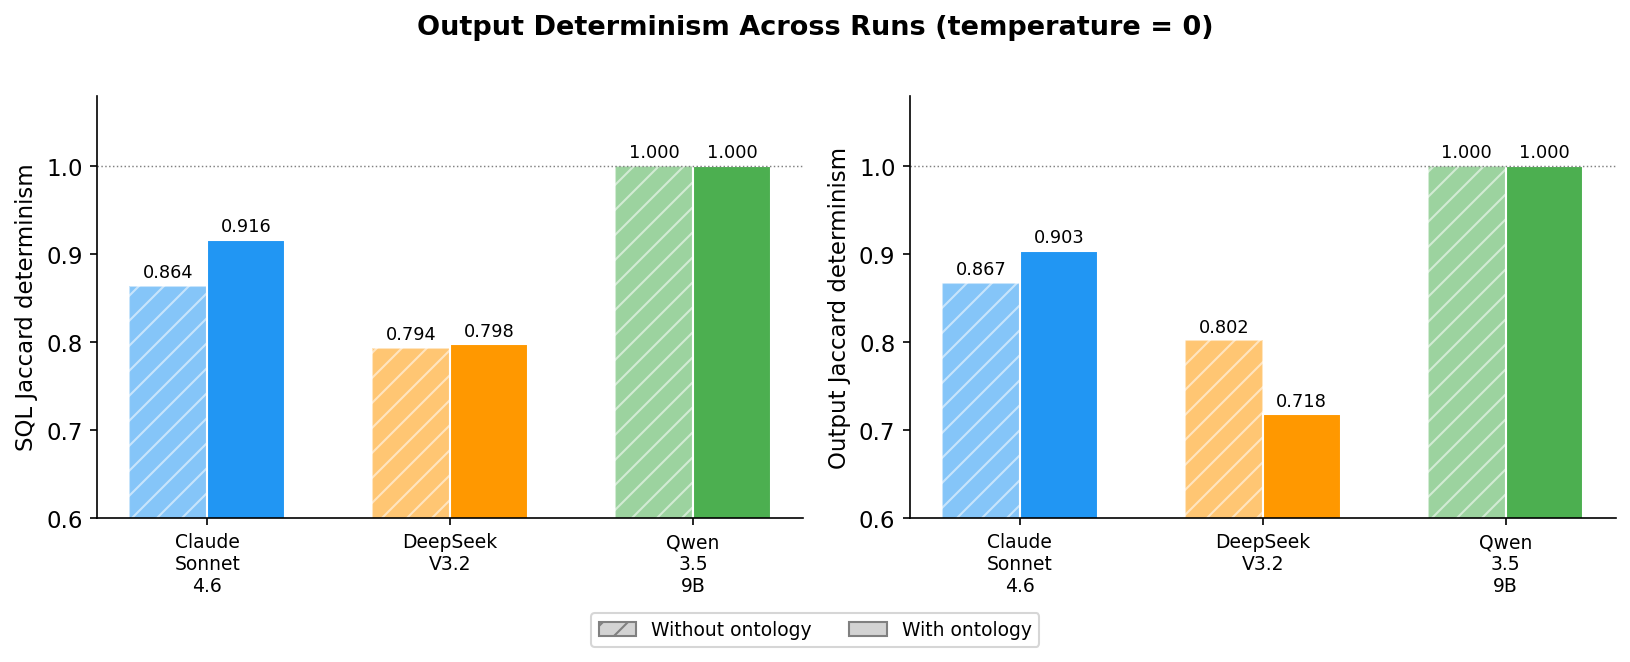

In [84]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle('Output Determinism Across Runs (temperature = 0)',
             fontsize=13, fontweight='bold', y=1.01)

det_keys = [
    ('mean_determinism_sql_similarity',    'SQL Jaccard determinism'),
    ('mean_determinism_output_similarity', 'Output Jaccard determinism'),
]

x = np.arange(len(MODELS))
w = 0.32

for ax, (key, ylabel) in zip(axes, det_keys):
    base_vals = [m(model, onto=False, key=key) for model in MODELS]
    onto_vals = [m(model, onto=True,  key=key) for model in MODELS]
    colors = [COLORS[model] for model in MODELS]

    b1 = ax.bar(x - w/2, base_vals, width=w, color=colors, alpha=0.55,
                edgecolor='white', hatch='//')
    b2 = ax.bar(x + w/2, onto_vals, width=w, color=colors, alpha=1.0,
                edgecolor='white')

    for bars in [b1, b2]:
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.005,
                    f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8.5)

    ax.set_xticks(x)
    ax.set_xticklabels([LABELS[model].replace(' ', '\n') for model in MODELS], fontsize=9)
    ax.set_ylim(0.6, 1.08)
    ax.set_ylabel(ylabel)
    ax.axhline(1.0, color='grey', linewidth=0.7, linestyle=':')

cond_handles = [
    mpatches.Patch(facecolor='lightgrey', hatch='//', edgecolor='grey', label='Without ontology'),
    mpatches.Patch(facecolor='lightgrey', edgecolor='grey',             label='With ontology'),
]
fig.legend(handles=cond_handles, loc='lower center',
           ncol=2, bbox_to_anchor=(0.5, -0.06), fontsize=9)

plt.tight_layout()
plt.savefig('figures/4_5_1_determinism.png', dpi=300, bbox_inches='tight')
plt.show()

## 4.5.2 – Latency and Tool Calls

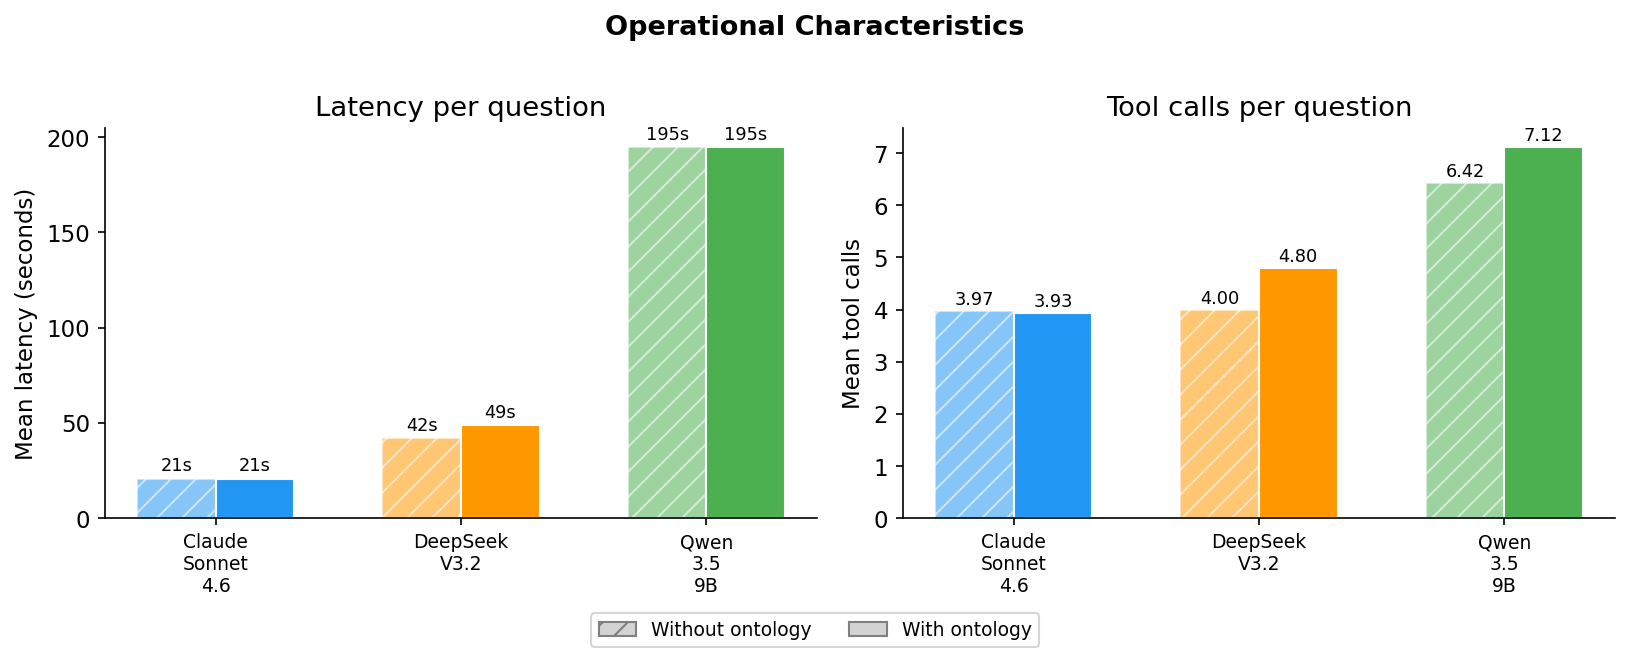

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle('Operational Characteristics', fontsize=13, fontweight='bold', y=1.01)

x = np.arange(len(MODELS))
w = 0.32

# Latency
ax = axes[0]
base_lat = [m(model, onto=False, key='mean_elapsed_seconds_per_question') for model in MODELS]
onto_lat = [m(model, onto=True,  key='mean_elapsed_seconds_per_question') for model in MODELS]
colors   = [COLORS[model] for model in MODELS]

b1 = ax.bar(x - w/2, base_lat, width=w, color=colors, alpha=0.55,
            edgecolor='white', hatch='//')
b2 = ax.bar(x + w/2, onto_lat, width=w, color=colors, alpha=1.0,
            edgecolor='white')
for bars in [b1, b2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 2,
                f'{bar.get_height():.0f}s', ha='center', va='bottom', fontsize=8.5)
ax.set_xticks(x)
ax.set_xticklabels([LABELS[model].replace(' ', '\n') for model in MODELS], fontsize=9)
ax.set_ylabel('Mean latency (seconds)')
ax.set_title('Latency per question')

# Tool calls
ax = axes[1]
base_calls = [m(model, onto=False, key='mean_num_calls_per_question') for model in MODELS]
onto_calls = [m(model, onto=True,  key='mean_num_calls_per_question') for model in MODELS]

b1 = ax.bar(x - w/2, base_calls, width=w, color=colors, alpha=0.55,
            edgecolor='white', hatch='//')
b2 = ax.bar(x + w/2, onto_calls, width=w, color=colors, alpha=1.0,
            edgecolor='white')
for bars in [b1, b2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.05,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8.5)
ax.set_xticks(x)
ax.set_xticklabels([LABELS[model].replace(' ', '\n') for model in MODELS], fontsize=9)
ax.set_ylabel('Mean tool calls')
ax.set_title('Tool calls per question')

cond_handles = [
    mpatches.Patch(facecolor='lightgrey', hatch='//', edgecolor='grey', label='Without ontology'),
    mpatches.Patch(facecolor='lightgrey', edgecolor='grey',             label='With ontology'),
]
fig.legend(handles=cond_handles, loc='lower center',
           ncol=2, bbox_to_anchor=(0.5, -0.06), fontsize=9)

plt.tight_layout()
plt.savefig('figures/4_5_2_latency_calls.png', dpi=300, bbox_inches='tight')
plt.show()